# DSP pipeline — *KON-Artist model*

### Objective: Adversarial DSP Pipeline for Audio Spoofing Detection

This notebook implements a non-differentiable, black-box audio generation pipeline designed for Reinforcement Learning (RL). The objective is to bridge the "naturalness gap" between synthetic and bonafide speech by simulating physiological and environmental artifacts. By manipulating micro-prosody (jitter/shimmer), spectral envelopes (tilt/harmonics), and channel degradations (codecs), the pipeline provides a search space for an RL Actor to expose structural vulnerabilities in modern Graph Attention-based detectors like AASIST3.

### Requirements

In [1]:
# --- STEP 1: TOTAL CLEANUP ---
# Uninstall everything to avoid conflicts between versions 2.5 and 2.11
!pip uninstall -y torch torchaudio torchvision torchcodec torchfx nvidia-nccl-cu12 nvidia-cudnn-cu12

# Physical deletion of folders to avoid "circular import" and "partially initialized" errors
!rm -rf /usr/local/lib/python3.12/dist-packages/torch*
!rm -rf /usr/local/lib/python3.12/dist-packages/nvidia*
!pip cache purge

# --- STEP 2: SYSTEM DEPENDENCIES ---
# Install FFmpeg and the development libraries required by torchcodec and torchaudio
!apt-get update && apt-get install -y ffmpeg libavcodec-dev libavformat-dev libavutil-dev

# --- STEP 3: COORDINATED INSTALLATION (CUDA 12.1) ---
# Use version 2.5.1, which is currently the most stable for research
!pip install torch==2.5.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

# --- STEP 4: AUDIO LIBRARIES ---
# Install torch_audiomentations and torchcodec compatible with 2.5.1
!pip install torch-audiomentations==0.12.0
!pip install torchcodec==0.2.0

# Librosa is optional, but we include it if analysis utilities needed
#!pip install librosa

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Found existing installation: torchcodec 0.11.0
Uninstalling torchcodec-0.11.0:
  Successfully uninstalled torchcodec-0.11.0
Found existing installation: torchfx 0.5.1
Uninstalling torchfx-0.5.1:
  Successfully uninstalled torchfx-0.5.1
Found existing installation: nvidia-nccl-cu12 2.21.5
Uninstalling nvidia-nccl-cu12-2.21.5:
  Successfully uninstalled nvidia-nccl-cu12-2.21.5
Found existing installation: nvidia-cudnn-cu12 9.1.0.70
Uninstalling nvidia-cudnn-cu12-9.1.0.70:
  Successfully uninstalled nvidia-cudnn-cu12-9.1.0.70
Files removed: 209
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-proje

# Integrated Pipeline

To prevent effects from cancelling each other out, we will follow this sequence:
1.  **Vocal Source:** **Jitter & Shimmer** (adds "organic" micro-instability).
2.  **Spectral Shaping:** **Spectral Tilt** & **Harmonic Saturation** (fixes the macro-envelope).
3.  **Dynamics:** **Compression** (`torch-audio-effects`) to glue the perturbations.
4.  **Environment:** **Reverb & Noise** (`torch-audiomentations`).
5.  **Channel:** **Encoding Compression** (`torchaudio.io.AudioEffector`) to hide the evidence.
6.  **Adversarial Normalization**.

## Implementation details

### 1. Source Perturbations (Micro-Prosody)
The pipeline begins at the "vocal source" level, introducing stochastic instabilities that mimic human physiological imperfections.

* **Shimmer (Amplitude):** Modulates the signal's envelope using stochastic noise to break the unnatural constant amplitude often found in synthetic speech.

$$A_{n} = (1 + \text{shimmer level} \cdot \eta_n) \cdot x_n$$
<center>where $\eta_n$ represents filtered noise.</center>
    
* **Jitter (Phase/Frequency):** Implemented as a phase-shift approximation. It adds random timing perturbations to the waveform to counter the perfect periodicity of neural vocoders.


### 2. Spectral & Harmonic Shaping
This stage targets the frequency-domain signatures (spectral centroid and slope) that state-of-the-art detectors like AASIST3 prioritize.

* **Spectral Tilt:** Uses a `lowpass_biquad` filter at a 2kHz cutoff combined with a gain multiplier. This allows the RL agent to rotate the spectrum, compensating for the "dull" high-frequency response typical of many spoofing models.
* **Harmonic Enrichment:** Employs a `tanh` saturation function. By driving the signal into non-linear distortion, the pipeline generates additional odd harmonics, effectively "filling in" spectral gaps and adding perceived "warmth" or energy to the upper frequencies.

    $$x_{harmonics} = \tanh(x \cdot (1 + \text{drive}))$$


### 3. Dynamic Range Control
To mask the energy transients and vocoder-specific artifacts, the pipeline applies a custom **Dynamic Range Compressor**.

* **Logarithmic Peak Detection:** Converts the signal to the dB scale to identify peaks relative to a controlled threshold.
* **Gain Reduction:** Compresses peaks exceeding the `threshold_db` based on a variable `ratio`. This flattens the signal, making it harder for a detector to find "tell-tale" bursts of energy in specific sub-bands.


### 4. Physical Channel & Codec Simulation
This section simulates the "transfer function" of real-world scenarios, such as a replay attack or a VOIP call.

* **Stochastic Environment (Placeholders):** The architecture includes hooks for `AddBackgroundNoise` and `ApplyImpulseResponse` (RIR) to simulate room acoustics and microphone floor noise.
* **Lossy Codec Compression:** Uses `torchaudio.io.CodecConfig` to simulate MP3 encoding. By passing the audio through an `io.BytesIO` buffer, it strips away high-frequency phase information and introduces encoding artifacts that can effectively "smear" the synthetic signatures the model is trained to detect.


### 5. Adversarial Normalization
The final step is a **Peak Normalization** layer. This is a critical defensive bypass:
* **Volume Neutralization:** It ensures the audio is scaled to its maximum absolute value.
* **Strategic Intent:** This prevents the spoofing detector from using simple volume changes or global energy levels as a heuristic for detection, forcing it to rely on deeper, more complex acoustic features.

---



**Critical Note:**

While these effects improve "naturalness," over-processing can lead to signal degradation that makes the spoofing attempt obvious to human listeners, even if it bypasses the machine detector. The RL agent's reward function must strictly balance **spoofing success** against **perceptual quality (PESQ/STOI)** to ensure the attacks remain "stealthy."

## Pipeline class

❕	Reverb and Noise are comented by now because they require input files to work (yet to be downloaded).

**Reference Datasets:**
- **Noise (`noise_tensor`):** [**MUSAN Dataset**](https://www.openslr.org/17/) is the standard for speech research. It includes three categories: Speech (babble), Music, and Noise (ambient).
- **Reverb (`ir_tensor`):** [**MIT Impulse Response Survey**](https://mcdermottlab.mit.edu/Reverb/IR_Survey.html) High-fidelity IRs from many everyday environments. 

In [ ]:
# Original snippet for reference (not to be included in the final code):
# Uses torch_audiomentations for noise and reverb, which are critical for simulating real-world conditions in replay attacks.

# from torch_audiomentations import AddBackgroundNoise, ApplyImpulseResponse

# class AdvancedDSPPipeline(torch.nn.Module):
#     def __init__(self, sample_rate=16000):
        # (…)
        # Stochastic ambient effects
        # Noise addition (Simulates mic floor noise)
        #self.noise = AddBackgroundNoise(background_paths="path/to/noise_folder", p=1.0)
        # Reverb via RIR (Critical for Replay Attacks)
        #self.reverb = ApplyImpulseResponse(ir_paths="path/to/ir_folder", p=1.0)

#     def forward(self, audio, params):
        # (…)
        # 4. Environment (Stochastic)
        #x = self.reverb(x.unsqueeze(0), sample_rate=self.sr)
        #x = self.noise(x, sample_rate=self.sr).squeeze(0)

In [ ]:
import io
import torch
import torchaudio
import torchaudio.functional as F
import numpy as np

# Class definition with fixed imports and error handling
class AdvancedDSPPipeline(torch.nn.Module):
    def __init__(self, sample_rate=16000):
        super().__init__()
        self.sr = sample_rate
        # Codec to hide artifacts (torchaudio 2.11 API)
        # self.codec = torchaudio.transforms.Codec(format="mp3")

    def apply_codec_simulation(self, x, format="mp3", bitrate=64000):
        """Simulates codec compression."""
        # Later we can add more parameters here for the RL to manipulate
        config = torchaudio.io.CodecConfig(bit_rate=bitrate)
        buffer = io.BytesIO()
        # We pass 'config' instead of the string directly
        torchaudio.save(buffer, x.cpu(), self.sr, format=format, compression=config)
        buffer.seek(0)
        x_compressed, _ = torchaudio.load(buffer)
        return x_compressed.to(x.device)

    def apply_spectral_tilt(self, x, tilt_db_per_octave):
        """Adjusts the spectral tilt."""
        # Simple implementation: first-order filter
        # The RL agent controls the high-frequency gain
        return F.lowpass_biquad(x, self.sr, cutoff_freq=2000, Q=0.707) * (1 + tilt_db_per_octave)

    def apply_harmonics(self, x, drive):
        """Generates harmonics via non-linear distortion (Saturation)."""
        # 'drive' controls how much 'warmth' or distortion is added
        return torch.tanh(x * (1 + drive))

    def apply_jitter_shimmer(self, x, jitter_level, shimmer_level):
        """Micro-variations in frequency and amplitude."""
        # 'torch.randn_like(x)' can be a low-pass filtered Gaussian noise

        # Shimmer: Stochastic amplitude modulation
        if shimmer_level > 0:
            noise = torch.randn_like(x) * shimmer_level
            x = x * (1.0 + noise)

        # Jitter: Simulation via a variable micro-delay (phase jitter)
        if jitter_level > 0:
            # Create a random phase shift
            phase_shift = torch.randn_like(x) * jitter_level
            x = x + phase_shift # Simplified approximation for the attack

        return x

    def apply_compression(self, x, threshold_db, ratio):
        """Basic dynamic range compressor."""
        # Convert to logarithmic scale to detect peaks
        x_db = 20 * torch.log10(torch.abs(x) + 1e-6)
        # Apply gain reduction above the threshold
        mask = x_db > threshold_db
        gain_reduction = (x_db[mask] - threshold_db) * (1 - 1/ratio)
        x_db[mask] -= gain_reduction
        return 10**(x_db / 20) * torch.sign(x) # Return to linear scale
    
    def apply_noise(self, x, noise_tensor, snr_db):
        """
        Injects noise at a specific SNR.
        Formula: SNR_db = 10 * log10(P_signal / P_noise)
        """
        # Ensure noise_tensor is the same length as x
        if noise_tensor.size(-1) > x.size(-1):
            noise_tensor = noise_tensor[:, :x.size(-1)]
        
        p_signal = x.pow(2).mean()
        p_noise = noise_tensor.pow(2).mean()
        
        # Calculate required gain for noise
        # P_noise_target = P_signal / 10^(SNR/10)
        snr_linear = 10 ** (snr_db / 10)
        gain = torch.sqrt(p_signal / (snr_linear * p_noise + 1e-9))
        
        return x + gain * noise_tensor
        
    def apply_reverb(self, x, ir_tensor, wet_dry=0.3):
        """
        Applies reverb via FFT convolution.
        'wet_dry' 0.0 is pure signal, 1.0 is pure reverb.
        """
        # Normalize IR energy to preserve signal volume
        ir_tensor = ir_tensor / (torch.norm(ir_tensor, p=2) + 1e-9)
        
        # torchaudio.functional.fftconvolve is efficient for long IRs
        # Ensure x and ir_tensor are [batch, channel, time] or [channel, time]
        wet = F.fftconvolve(x, ir_tensor, mode="full")
        
        # Truncate to original length
        wet = wet[..., :x.size(-1)]
        
        return (1 - wet_dry) * x + wet_dry * wet

    def forward(self, audio, params):
        # Ensure input is 2D [Channels, Samples]
        x = audio

        # 1. Vocal Source: Jitter & Shimmer
        x = self.apply_jitter_shimmer(x, params['jitter'], params['shimmer'])
        
        # 2. Spectral Shaping: Tilt & Harmonics
        x = self.apply_spectral_tilt(x, params['tilt'])
        x = self.apply_harmonics(x, params['harmonics'])
        
        # 3. Dynamics: Compression
        x = self.apply_compression(x, params['threshold'], params['ratio'])
        
        # 4. Environment (Stochastic)
        # Pass the noise/RIR tensors from your dataset here
        # if 'noise_tensor' in params and 'snr' in params:
        #     x = self.apply_noise(x, params['noise_tensor'], params['snr'])
        # if 'rir_tensor' in params and 'reverb_wet' in params:
        #     x = self.apply_reverb(x, params['rir_tensor'], params['reverb_wet'])
        
        # 5. Codec Simulation
        bitrate = params.get('bitrate', '128k')
        x = self.apply_codec_simulation(x, bitrate=bitrate)

        # Final Normalization (Crucial for AASIST3)
        # Prevents the model from detecting spoofing solely based on volume changes
        if x.abs().max() > 0:
            x = x / x.abs().max()

        return x

## Usage example

#### Loading sample

In [4]:
import torchaudio

# Load the .opus file
# torchaudio.load automatically detects the backend (FFmpeg is standard for .opus)
audio, sr = torchaudio.load('sample.opus')

# Note: torchaudio returns a tensor of shape [channels, samples]
# If you need it to be identical to librosa (mono and 1D), we use squeeze:
if audio.shape[0] > 1:
    audio = torch.mean(audio, dim=0) # Mixdown to mono if necessary
else:
    audio = audio.squeeze(0)

print(f"Sample Rate: {sr}")
print(f"Audio Shape: {audio.shape}")
print(f"Type: {type(audio)}") # Will return <class 'torch.Tensor'>

Sample Rate: 48000
Audio Shape: torch.Size([550936])
Type: <class 'torch.Tensor'>


In [5]:
from IPython.display import Audio

Audio(audio, rate=sr)

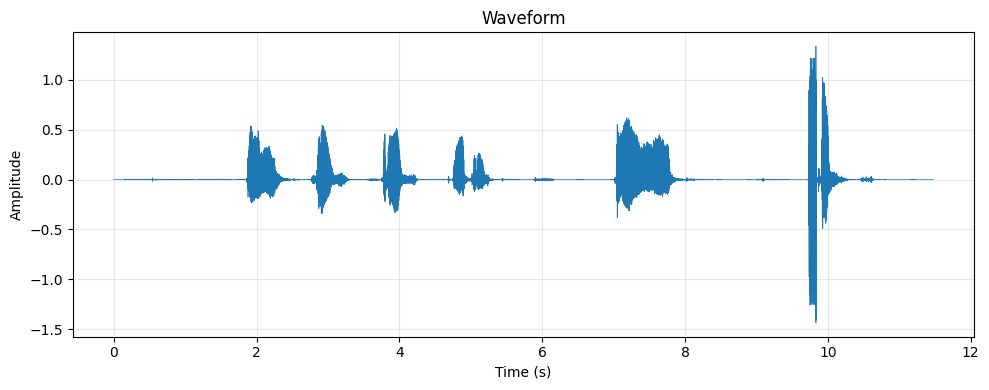

In [10]:
import torch
import matplotlib.pyplot as plt

def show_wave(audio, sr, title=None):
    # Asegurarnos de que el audio sea 1D [samples]
    if audio.dim() > 1:
        audio = audio.squeeze()

    audio_np = audio.cpu().numpy()
    # Crear eje de tiempo en segundos
    time_axis = torch.linspace(0, len(audio_np) / sr, steps=len(audio_np))

    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, audio_np, linewidth=0.5, color='#1f77b4')

    plt.title(f'{title} (Waveform)' if title else 'Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Uso:
show_wave(audio, sr)

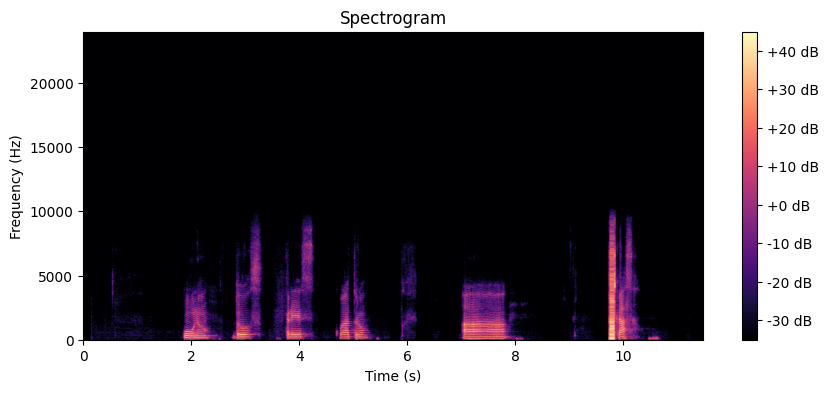

In [14]:
import torchaudio.transforms as T

def show_spect(audio, sr, n_fft=2048, hop_length=512, title=None):
    # 1. Definir la transformación (Power=2 para espectrograma de energía)
    # n_fft y hop_length alineados con tu código anterior
    spectrogram_transform = T.Spectrogram(
        n_fft=n_fft,
        hop_length=hop_length,
        power=2
    )

    # 2. Calcular espectrograma y convertir a DB
    # center=True en torchaudio emula el comportamiento por defecto de librosa
    spect = spectrogram_transform(audio)
    spect_db = T.AmplitudeToDB(stype='power', top_db=80)(spect)

    # 3. Graficar con imshow
    plt.figure(figsize=(10, 4))
    # 'extent' define los límites de los ejes: [izquierda, derecha, abajo, arriba]
    img = plt.imshow(
        spect_db.squeeze().cpu().numpy(),
        aspect='auto',
        origin='lower',
        extent=[0, audio.shape[-1]/sr, 0, sr/2],
        cmap='magma'
    )

    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'{title} (Spectrogram)' if title else 'Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.show()

# Uso:
show_spect(audio, sr)

----

### Testing

In [19]:
# 1. Instantiate the pipeline
pipeline = AdvancedDSPPipeline(sample_rate=sr)

# 2. Define the parameters (RL Actions)
# These should be mapped from the agent's [-1, 1] output to real ranges
params = {
    'jitter': 0.001,     # Micro-delay variance
    'shimmer': 0.02,     # Amplitude modulation intensity
    'tilt': -2.5,        # dB per octave slope
    'harmonics': 0.5,    # Saturation drive
    'threshold': -20.0,  # Compressor threshold in dB
    'ratio': 4.0,        # Compressor ratio
    'bitrate': 64000     # Codec settings
}

In [20]:
# Convert numpy array to torch tensor
if isinstance(audio, np.ndarray):
    audio_tensor = torch.from_numpy(audio).float()
else:
    audio_tensor = audio.float()

# Ensure audio has a batch dimension [1, Channels, Samples] or [1, Samples]
if audio_tensor.dim() == 1:
    # [Samples] -> [1, 1, Samples]
    audio_input = audio_tensor.unsqueeze(0).unsqueeze(0)
elif audio_tensor.dim() == 2:
    # [Channels, Samples] -> [1, Channels, Samples]
    audio_input = audio_tensor.unsqueeze(0)
else:
    audio_input = audio_tensor

# Apply the pipeline
# The pipeline expectation is (Channels, Samples) after the initial squeeze
processed_audio = pipeline(audio_input.squeeze(0), params)

# Result is [Channels, Samples]
print(f"Original shape: {audio.shape}")
print(f"Processed shape: {processed_audio.shape}")

Original shape: torch.Size([550936])
Processed shape: torch.Size([1, 550936])


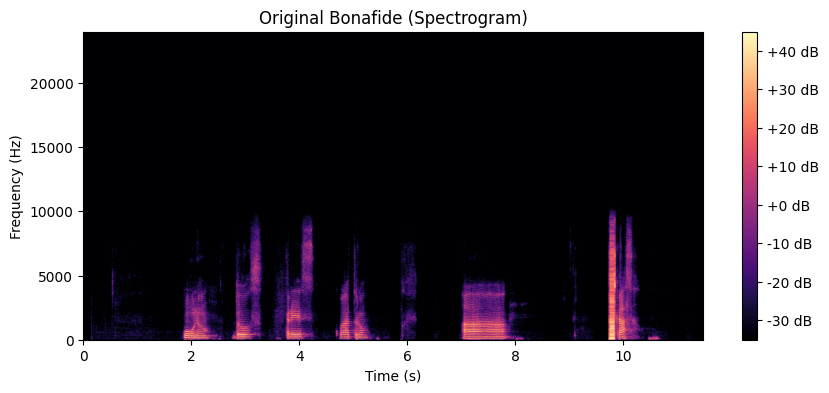

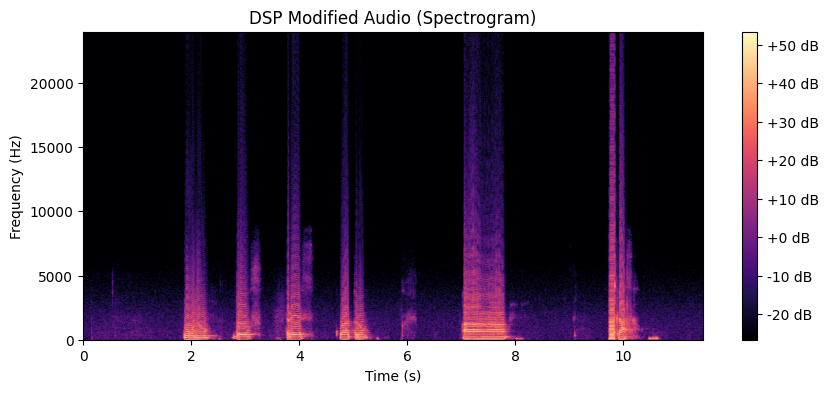

In [26]:
# Compare Original vs Processed
show_spect(audio_input.squeeze(0), sr, title="Original Bonafide")
show_spect(processed_audio.squeeze(0), sr, title="DSP Modified Audio")

In [ ]:
Audio(processed_audio, rate=sr)